## Cell 1: Imports & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Add src to path to use our utils
sys.path.append(os.path.abspath(os.path.join('..', 'src')))
from utils import load_raw_data, setup_logging

setup_logging()
sns.set_theme(style="whitegrid", palette="muted")

# Load Data
df = load_raw_data('../data/KUfacility_register_data_for_uploadWAISWAetalPLOSONE82020.xlsx')

# Filter for Kenya (country == 2) as per project scope
df_kenya = df[df['country'] == 2].copy()
print(f"Total records: {len(df_kenya)}")
df_kenya.head()

2026-07-07 20:36:31 | INFO     | utils | Loading data from ../data/KUfacility_register_data_for_uploadWAISWAetalPLOSONE82020.xlsx...


c:\ProgramData\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


2026-07-07 20:36:44 | INFO     | utils | Successfully loaded data with shape: (61018, 22)
Total records: 42247


,id,country,facility_coded,referral_in,apgar_1,apgar_5,sex,baby_discharge_status,multiple,bba,...,record_type,mothers_age_cat,c_mother_status,c_cat_ga,c_cat_bw,c_mode_of_delivery,quarter,c_baby_status,c_birth_outcome,c_birth_weight_g2
0,162230,2,HF0004,1,7.0,9.0,Male,NaN,1.0,0,...,Birth,≤19,Discharged_Alive,28-30wks,1000-1499g,Vaginal_Delivery,Q1,Undocumented_LB,Born_Alive,1400.0
1,127964,2,HF0005,NaN,NaN,NaN,NaN,NaN,1.0,0,...,Discharge_Preg,≤19,Discharged_Alive,NaN,NaN,NaN,Q2,Undocumented_LB,Born_Alive,NaN
2,148113,2,HF0006,0,NaN,NaN,NaN,NaN,1.0,0,...,Discharge_Preg,≤19,Discharged_Alive,NaN,NaN,NaN,Q4,Undocumented_LB,Born_Alive,NaN
6,113822,2,HF0005,NaN,NaN,NaN,NaN,NaN,1.0,0,...,Abortion,≤19,NaN,NaN,NaN,NaN,Q1,Unknown_Still_Birth,Still_Birth,NaN
7,130599,2,HF0005,NaN,NaN,NaN,NaN,NaN,1.0,0,...,Discharge_Preg,≤19,Transferred_to_Another_Facility,37wks+,NaN,NaN,Q3,Undocumented_LB,Born_Alive,NaN


## Target Variable Definition & Distribution

2026-07-07 20:36:51 | INFO     | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-07 20:36:51 | INFO     | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


C:\Users\Administrator\AppData\Local\Temp\ipykernel_9884\1251313218.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='adverse_outcome', data=df_kenya, palette=['#2ca02c', '#d62728'], ax=ax)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_9884\1251313218.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Normal (0)', 'Adverse (1)'])


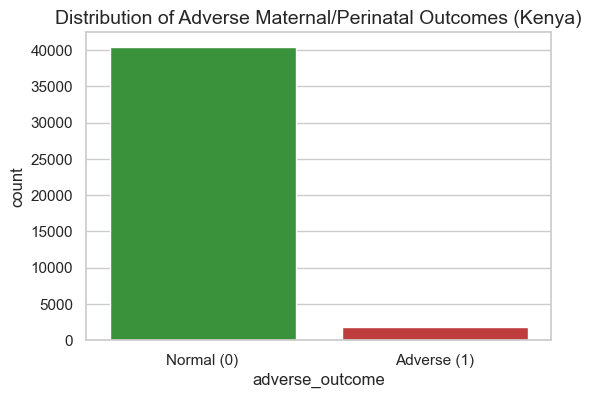

Class Imbalance:
adverse_outcome
0    0.958127
1    0.041873
Name: proportion, dtype: float64


In [2]:
# Define Adverse Outcome based on Data Dictionary
adverse_conditions = ['Fresh_Still_Birth', 'Macerated_Still_Birth', 'Immediate_Neonatal_Death']
df_kenya['adverse_outcome'] = (
    (df_kenya['c_mother_status'] == 'Died') | 
    (df_kenya['c_baby_status'].isin(adverse_conditions))
).astype(int)

# Plot Target Distribution
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x='adverse_outcome', data=df_kenya, palette=['#2ca02c', '#d62728'], ax=ax)
ax.set_title('Distribution of Adverse Maternal/Perinatal Outcomes (Kenya)', fontsize=14)
ax.set_xticklabels(['Normal (0)', 'Adverse (1)'])
plt.show()

# Calculate Imbalance Ratio
imbalance = df_kenya['adverse_outcome'].value_counts(normalize=True)
print(f"Class Imbalance:\n{imbalance}")

## Maternal Age & Referral Status vs Outcomes

C:\Users\Administrator\AppData\Local\Temp\ipykernel_9884\1888797687.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='mothers_age_cat', y='adverse_outcome', data=df_kenya, ax=axes[0], palette='Reds_r')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_9884\1888797687.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='referral_in', y='adverse_outcome', data=df_kenya, ax=axes[1], palette=['#1f77b4', '#ff7f0e'])
C:\Users\Administrator\AppData\Local\Temp\ipykernel_9884\1888797687.py:11: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x='referral_in', y='adverse_outcome', data=df_kenya, ax=a

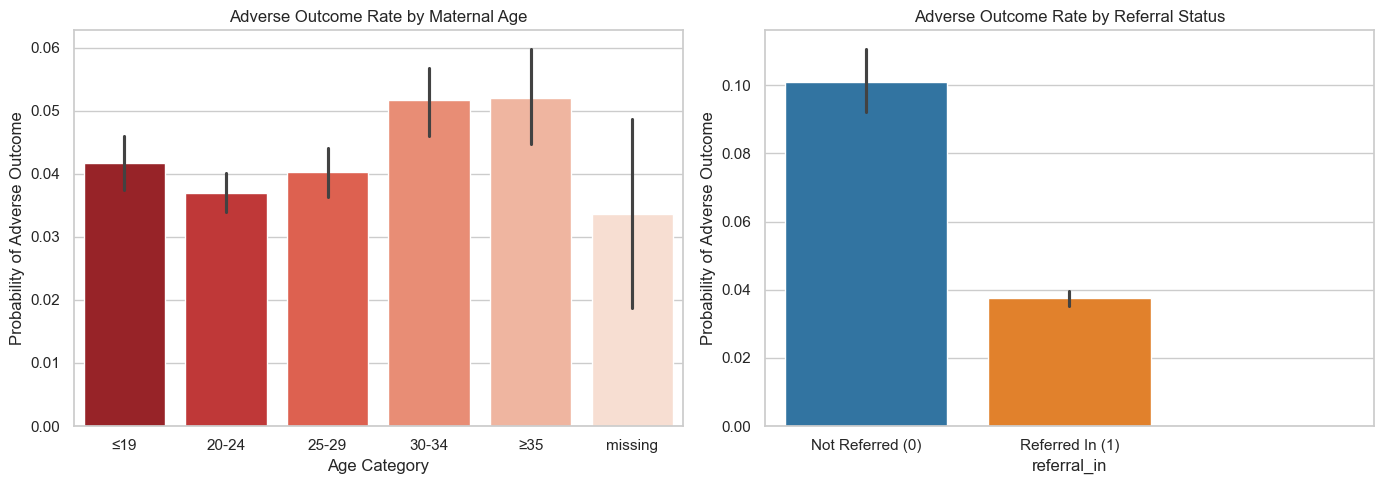

In [3]:
# Clinical Insight: Age and Referral are strong predictors
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age Category
sns.barplot(x='mothers_age_cat', y='adverse_outcome', data=df_kenya, ax=axes[0], palette='Reds_r')
axes[0].set_title('Adverse Outcome Rate by Maternal Age', fontsize=12)
axes[0].set_ylabel('Probability of Adverse Outcome')
axes[0].set_xlabel('Age Category')

# Referral Status
sns.barplot(x='referral_in', y='adverse_outcome', data=df_kenya, ax=axes[1], palette=['#1f77b4', '#ff7f0e'])
axes[1].set_title('Adverse Outcome Rate by Referral Status', fontsize=12)
axes[1].set_ylabel('Probability of Adverse Outcome')
axes[1].set_xticklabels(['Not Referred (0)', 'Referred In (1)'])

plt.tight_layout()
plt.show()

## Facility Level & Birth Weight Analysis

C:\Users\Administrator\AppData\Local\Temp\ipykernel_9884\1147784739.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='bw_clean', y='adverse_outcome', data=df_kenya, order=bw_order, ax=axes[0], palette='coolwarm')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_9884\1147784739.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='c_cat_ga', y='adverse_outcome', data=df_kenya, order=ga_order, ax=axes[1], palette='coolwarm')


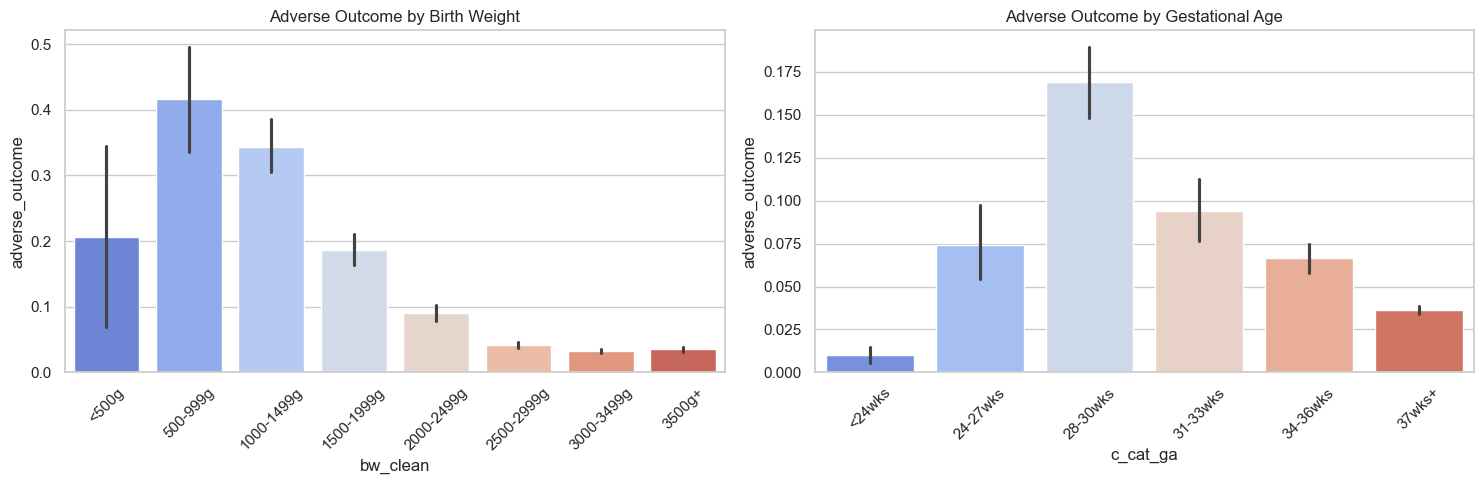

In [4]:
# Map Facility Codes to simulated Levels for visualization (or use raw codes)
# For EDA, let's look at Birth Weight Categories (c_cat_bw) and Gestational Age (c_cat_ga)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Birth Weight
bw_order = ['<500g', '500-999g', '1000-1499g', '1500-1999g', '2000-2499g', '2500-2999g', '3000-3499g', '3500g+']
# Clean up actual data dictionary values for plotting
bw_map = {'<500g': '<500g', '500-999g': '500-999g', '1000-1499g': '1000-1499g', 
          '1500-1999g': '1500-1999g', '2000-2499g': '2000-2499g', '2500-2999g': '2500-2999g', 
          '3000-3499g': '3000-3499g', '3500g+': '3500g+'}
df_kenya['bw_clean'] = df_kenya['c_cat_bw'].map(bw_map)

sns.barplot(x='bw_clean', y='adverse_outcome', data=df_kenya, order=bw_order, ax=axes[0], palette='coolwarm')
axes[0].set_title('Adverse Outcome by Birth Weight', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Gestational Age
ga_order = ['<24wks', '24-27wks', '28-30wks', '31-33wks', '34-36wks', '37wks+']
sns.barplot(x='c_cat_ga', y='adverse_outcome', data=df_kenya, order=ga_order, ax=axes[1], palette='coolwarm')
axes[1].set_title('Adverse Outcome by Gestational Age', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [5]:
# Count plot of segments
plt.figure(figsize=(10, 6))
sns.countplot(y='knn_segment_name', data=df_segmented, palette='viridis', order=df_segmented['knn_segment_name'].value_counts().index)
plt.title('Distribution of Maternal Clinical Archetypes (KNN Segmentation)', fontsize=14)
plt.xlabel('Number of Patients')
plt.ylabel('Clinical Archetype')
plt.tight_layout()
plt.show()

# Business Insight generation
print("--- MoH Resource Allocation Insights ---")
for segment in df_segmented['knn_segment_name'].unique():
    count = len(df_segmented[df_segmented['knn_segment_name'] == segment])
    pct = (count / len(df_segmented)) * 100
    print(f"{segment}: {count} patients ({pct:.1f}%)")

NameError: name 'df_segmented' is not defined

<Figure size 1000x600 with 0 Axes>